# Block Sealing Analysis: Competitive Ratio, Variance, Two-Builder Competition, Distribution Sensitivity

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import simulation as sim

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Parameters
LAM  = 15.0   # transaction arrival rate
MU   = 1.0    # slot ending rate
B    = 50     # block gas capacity
SEED = 42

rng = np.random.default_rng(SEED)

# Generate one slot
T = rng.exponential(1.0 / MU)
n = rng.poisson(LAM * T)
values    = np.random.exponential(1.0, n)
gas_costs = np.random.randint(1, 6, n).astype(float)

print(f'Slot duration:      {T:.2f}s')
print(f'Transactions:       {n}')
print(f'Total value:        {values.sum():.3f} ETH')
print(f'Mean density (v/w): {np.mean(values/gas_costs):.3f}')
print(f'\nFirst 5 transactions:')
print(f'  values:    {values[:5].round(3)}')
print(f'  gas_costs: {gas_costs[:5].astype(int)}')
print(f'  densities: {(values[:5]/gas_costs[:5]).round(3)}')

Slot duration:      2.40s
Transactions:       35
Total value:        31.777 ETH
Mean density (v/w): 0.389

First 5 transactions:
  values:    [0.595 0.372 0.6   0.929 0.568]
  gas_costs: [4 1 5 1 1]
  densities: [0.149 0.372 0.12  0.929 0.568]


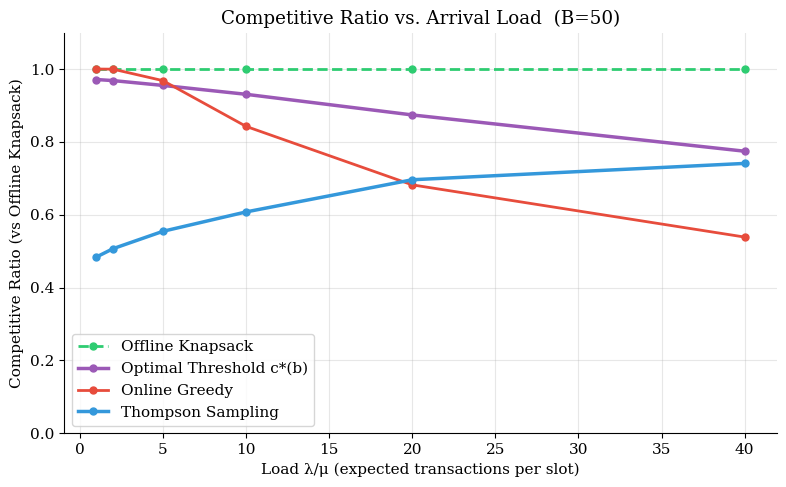

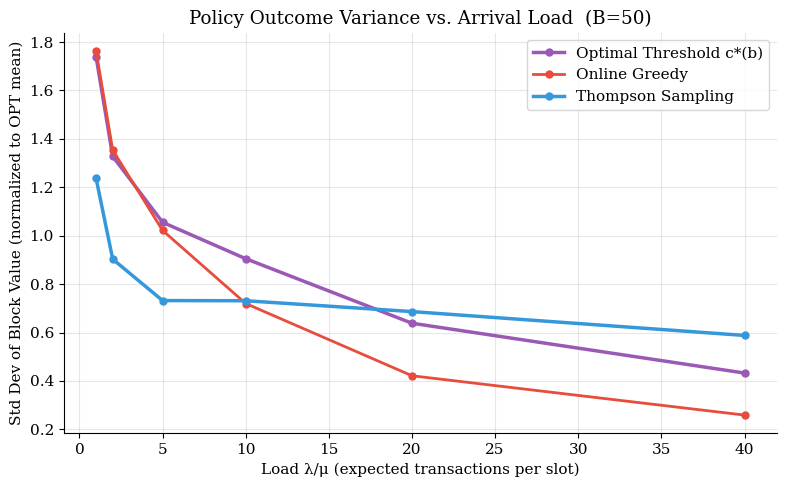

In [2]:
# Fig 1 & 2: Competitive Ratio and Variance vs Load

import os
os.makedirs('figures', exist_ok=True)

N_EPISODES = 2000
lam_values = [1, 2, 5, 10, 20, 40]
loads      = [l / MU for l in lam_values]

policies = ['offline_knapsack', 'threshold', 'greedy', 'thompson']
means    = {p: [] for p in policies}
stds     = {p: [] for p in policies}

rng = np.random.default_rng(SEED)
np.random.seed(SEED)
c_star = sim.compute_threshold(B=B, lam=LAM, mu=MU)

for lam in lam_values:
    bucket = {p: [] for p in policies}
    for _ in range(N_EPISODES):
        T_slot = rng.exponential(1.0 / MU)
        n      = rng.poisson(lam * T_slot)
        if n == 0:
            for p in policies: bucket[p].append(0.0)
            continue
        v = np.random.exponential(1.0, n)
        g = np.random.randint(1, 6, n).astype(float)
        bucket['offline_knapsack'].append(sim.offline_knapsack(v, g, B))
        bucket['threshold'].append(sim.apply_threshold(v, g, c_star, B))
        bucket['greedy'].append(sim.greedy_unsorted(v, g, B))
        ts_val, _ = sim.thompson_sampling(v, g, B, mu=MU)
        bucket['thompson'].append(ts_val)

    opt_mean = np.mean(bucket['offline_knapsack'])
    for p in policies:
        means[p].append(np.mean(bucket[p]) / opt_mean if opt_mean > 0 else 1.0)
        stds[p].append(np.std(bucket[p])  / opt_mean if opt_mean > 0 else 0.0)

labels = {
    'offline_knapsack': 'Offline Knapsack',
    'threshold':        'Optimal Threshold c*(b)',
    'greedy':           'Online Greedy',
    'thompson':         'Thompson Sampling',
}
styles = {
    'offline_knapsack': dict(color='#2ecc71', linestyle='--', linewidth=2),
    'threshold':        dict(color='#9b59b6', linewidth=2.5),
    'greedy':           dict(color='#e74c3c', linewidth=2),
    'thompson':         dict(color='#3498db', linewidth=2.5),
}

# Figure 1: Competitive Ratio
fig, ax = plt.subplots(figsize=(8, 5))
for p in policies:
    ax.plot(loads, means[p], marker='o', markersize=5, label=labels[p], **styles[p])
ax.set_xlabel('Load λ/μ (expected transactions per slot)')
ax.set_ylabel('Competitive Ratio (vs Offline Knapsack)')
ax.set_title('Competitive Ratio vs. Arrival Load  (B=50)')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig('figures/competitive_ratio.png', dpi=150)
plt.show()

# Figure 2: Variance vs Load (online policies only; normalized to OPT mean)
fig, ax = plt.subplots(figsize=(8, 5))
for p in ['threshold', 'greedy', 'thompson']:
    ax.plot(loads, stds[p], marker='o', markersize=5, label=labels[p], **styles[p])
ax.set_xlabel('Load λ/μ (expected transactions per slot)')
ax.set_ylabel('Std Dev of Block Value (normalized to OPT mean)')
ax.set_title('Policy Outcome Variance vs. Arrival Load  (B=50)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/variance_vs_load.png', dpi=150)
plt.show()

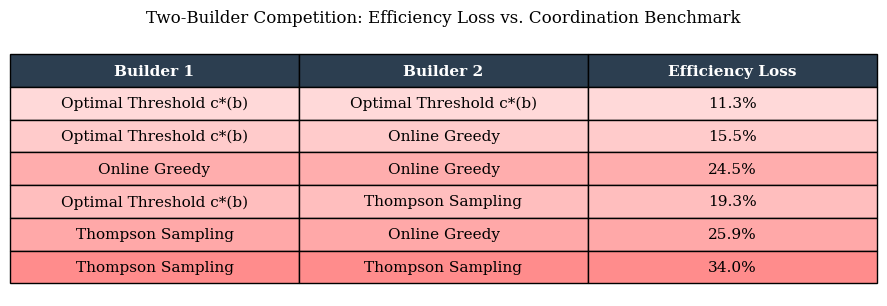

In [3]:
# Fig 3: Two-Builder Competition Table

N_EPISODES = 2000
rng2 = np.random.default_rng(SEED)
np.random.seed(SEED)
c_star_race = sim.compute_threshold(B=B, lam=LAM, mu=MU)

def run_policy(name, v, g):
    if len(v) == 0: return 0.0
    if name == 'Thompson Sampling':
        val, _ = sim.thompson_sampling(v, g, B, mu=MU)
        return val
    if name == 'Optimal Threshold c*(b)':
        return sim.apply_threshold(v, g, c_star_race, B)
    return sim.greedy_unsorted(v, g, B)

coord_opts = []
for _ in range(N_EPISODES):
    T_slot = rng2.exponential(1.0 / MU)
    n1 = rng2.poisson(LAM * T_slot); n2 = rng2.poisson(LAM * T_slot)
    v1 = np.random.exponential(1.0, n1) if n1 > 0 else np.array([])
    g1 = np.random.randint(1, 6, n1).astype(float) if n1 > 0 else np.array([])
    v2 = np.random.exponential(1.0, n2) if n2 > 0 else np.array([])
    g2 = np.random.randint(1, 6, n2).astype(float) if n2 > 0 else np.array([])
    coord_opts.append(max(sim.offline_knapsack(v1, g1, B),
                          sim.offline_knapsack(v2, g2, B)))
coord_opt_mean = np.mean(coord_opts)

matchups = [
    ('Optimal Threshold c*(b)', 'Optimal Threshold c*(b)'),
    ('Optimal Threshold c*(b)', 'Online Greedy'),
    ('Online Greedy',           'Online Greedy'),
    ('Optimal Threshold c*(b)', 'Thompson Sampling'),
    ('Thompson Sampling',       'Online Greedy'),
    ('Thompson Sampling',       'Thompson Sampling'),
]
losses = []
for p1, p2 in matchups:
    winners = []
    rng3 = np.random.default_rng(SEED + 1)
    for _ in range(N_EPISODES):
        T_slot = rng3.exponential(1.0 / MU)
        def draw():
            n = rng3.poisson(LAM * T_slot)
            if n == 0: return np.array([]), np.array([])
            return np.random.exponential(1.0, n), np.random.randint(1, 6, n).astype(float)
        v1, g1 = draw()
        v2, g2 = draw()
        winners.append(max(run_policy(p1, v1, g1), run_policy(p2, v2, g2)))
    losses.append(1.0 - np.mean(winners) / coord_opt_mean)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis('off')

cell_text = [[p1, p2, f'{loss:.1%}'] for (p1, p2), loss in zip(matchups, losses)]
col_labels = ['Builder 1', 'Builder 2', 'Efficiency Loss']
table = ax.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.9)

for j in range(3):
    table[(0, j)].set_facecolor('#2c3e50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# shade rows by loss magnitude (green = low loss, red = high loss)
max_loss = max(losses)
for i, loss in enumerate(losses):
    r = loss / max_loss
    color = (1.0, 1.0 - 0.45 * r, 1.0 - 0.45 * r)  # white → light red
    for j in range(3):
        table[(i + 1, j)].set_facecolor(color)

ax.set_title('Two-Builder Competition: Efficiency Loss vs. Coordination Benchmark',
             pad=14, fontsize=12)
plt.tight_layout()
plt.savefig('figures/two_builder_table.png', dpi=150, bbox_inches='tight')
plt.show()

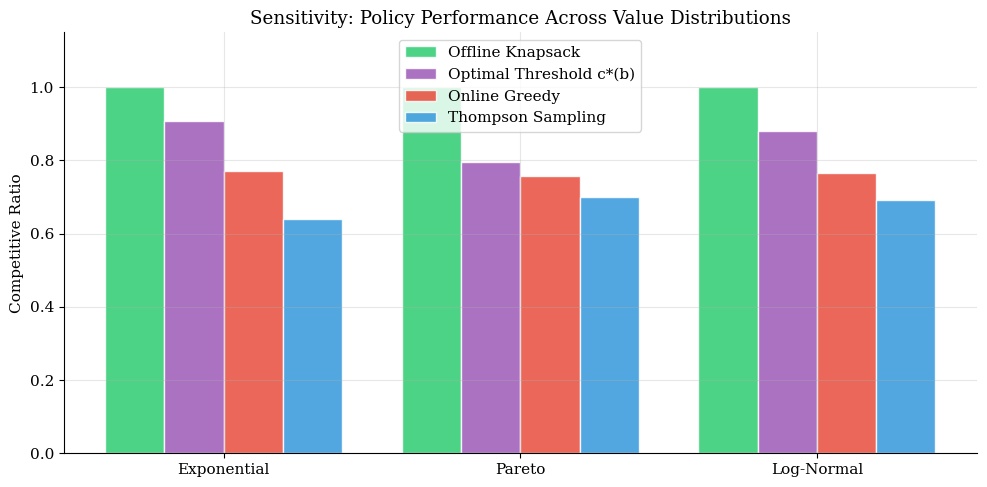

In [4]:
# Fig 4: Distribution Sensitivity

N_EPISODES = 1500
dists = {
    'Exponential': lambda n: np.random.exponential(1.0, n),
    'Pareto':      lambda n: (np.random.pareto(1.5, n) + 1),
    'Log-Normal':  lambda n: np.random.lognormal(0.0, 1.0, n),
}
policies = ['offline_knapsack', 'threshold', 'greedy', 'thompson']
sens_results = {}

np.random.seed(SEED)
c_star_sens = sim.compute_threshold(B=B, lam=LAM, mu=MU)

for dist_name, val_fn in dists.items():
    rng = np.random.default_rng(SEED)
    bucket = {p: [] for p in policies}
    for _ in range(N_EPISODES):
        T_slot = rng.exponential(1.0 / MU)
        n = rng.poisson(LAM * T_slot)
        if n == 0:
            for p in policies: bucket[p].append(0.0)
            continue
        v = val_fn(n)
        g = np.random.randint(1, 6, n).astype(float)
        bucket['offline_knapsack'].append(sim.offline_knapsack(v, g, B))
        bucket['threshold'].append(sim.apply_threshold(v, g, c_star_sens, B))
        bucket['greedy'].append(sim.greedy_unsorted(v, g, B))
        ts_val, _ = sim.thompson_sampling(v, g, B, mu=MU)
        bucket['thompson'].append(ts_val)
    opt_mean = np.mean(bucket['offline_knapsack'])
    sens_results[dist_name] = {p: np.mean(bucket[p])/opt_mean for p in policies}

labels = {
    'offline_knapsack': 'Offline Knapsack',
    'threshold':        'Optimal Threshold c*(b)',
    'greedy':           'Online Greedy',
    'thompson':         'Thompson Sampling',
}
colors = ['#2ecc71', '#9b59b6', '#e74c3c', '#3498db']
x = np.arange(len(dists))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (p, color) in enumerate(zip(policies, colors)):
    vals = [sens_results[d][p] for d in dists]
    ax.bar(x + i*width, vals, width, label=labels[p], color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(dists.keys())
ax.set_ylabel('Competitive Ratio')
ax.set_title('Sensitivity: Policy Performance Across Value Distributions')
ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
plt.savefig('figures/sensitivity.png', dpi=150)
plt.show()